In [4]:
import pandas as pd
import numpy as np
import time
import random
from collections import Counter
from scipy.sparse import lil_matrix
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt

# Step 1: Load and Preprocess Data 

def load_basket_data(file_path):
    """Load basket dataset and return transaction list"""
    transactions = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            items = line.strip().split()  # Item IDs as strings
            if items:
                transactions.append(items)
    return transactions


transactions = load_basket_data('E:/NTU\课程\数据挖掘/assignment2/example/Market-Basket-Analysis-master/Market-Basket-Analysis-master/Data/dataset2.txt')
print(f"Original data: {len(transactions)} transactions, {len(set(item for sublist in transactions for item in sublist))} unique items")

# Critical Optimization: Filter High-Frequency Items to Reduce Memory

# Calculate item frequencies to filter rare items
total_trans = len(transactions)
all_items = [item for sublist in transactions for item in sublist]
item_counts = Counter(all_items)

# Keep items with support ≥ 0.001 (adjust based on memory; higher = fewer items)
min_support_item = 0.001  # Items appearing in at least 0.1% of transactions
keep_items = {item for item, cnt in item_counts.items() if cnt / total_trans >= min_support_item}
print(f"Filtered to {len(keep_items)} high-frequency items (from original unique items)")

# Filter transactions to retain only high-frequency items (and non-empty transactions)
filtered_transactions = []
for trans in transactions:
    filtered = [item for item in trans if item in keep_items]
    if filtered:  # Keep non-empty transactions
        filtered_transactions.append(filtered)
print(f"Filtered to {len(filtered_transactions)} non-empty transactions")

# Step 2: Generate Datasets with Varied Sizes (Control Variables)
# Target transaction sizes 
max_possible = len(filtered_transactions)
target_sizes = [500, 1000, 2000, 3000, min(4000, max_possible)]  # 5 datasets as required
datasets = []

for size in target_sizes:
    if size > max_possible:
        continue
    # Random sampling to ensure consistent distribution
    sampled_trans = random.sample(filtered_transactions, size)
    # Calculate key metrics for validation (unique items and average width)
    sampled_unique = len(set(item for sublist in sampled_trans for item in sublist))
    sampled_avg_width = np.mean([len(t) for t in sampled_trans])
    datasets.append({
        "transaction_size": size,
        "transactions": sampled_trans,
        "unique_items": sampled_unique,
        "avg_width": sampled_avg_width
    })
    print(f"Dataset {size} transactions: {sampled_unique} unique items, avg width {sampled_avg_width:.2f}")



Original data: 88162 transactions, 16470 unique items
Filtered to 2117 high-frequency items (from original unique items)
Filtered to 86190 non-empty transactions
Dataset 500 transactions: 1425 unique items, avg width 7.89
Dataset 1000 transactions: 1745 unique items, avg width 7.31
Dataset 2000 transactions: 2040 unique items, avg width 7.69
Dataset 3000 transactions: 2100 unique items, avg width 7.70
Dataset 4000 transactions: 2111 unique items, avg width 7.79


In [5]:
# Step 3: FP-growth with Sparse Encoding (Reduce Memory Usage)

def sparse_encoder(transactions):
    """Convert transactions to sparse matrix (instead of dense DataFrame)"""
    te = TransactionEncoder()
    te.fit(transactions)  # Get all unique items in the subset
    n_items = len(te.columns_)
    n_trans = len(transactions)
    
    # Use sparse matrix (only store non-zero values)
    sparse_mat = lil_matrix((n_trans, n_items), dtype=bool)
    for i, trans in enumerate(transactions):
        # Get indices of items in this transaction
        item_indices = [te.columns_.index(item) for item in trans if item in te.columns_]
        sparse_mat[i, item_indices] = True  # Mark non-zero positions
    # Convert to sparse DataFrame (mlxtend compatible)
    return pd.DataFrame.sparse.from_spmatrix(sparse_mat, columns=te.columns_)

# Parameters (adjust based on filtered data)
min_support = 0.01    # Higher than before to reduce itemset count
min_confidence = 0.15

# Store FP-growth results
fp_results = []
print("\nRunning FP-growth...")
for data in datasets:
    trans = data["transactions"]
    size = data["transaction_size"]
    
    # Encode transactions as sparse matrix (memory-efficient)
    df_sparse = sparse_encoder(trans)
    
    # Run FP-growth and time it
    start = time.time()
    frequent_itemsets = fpgrowth(df_sparse, min_support=min_support, use_colnames=True)
    itemset_time = time.time() - start
    
    # Generate rules and time it
    start = time.time()
    if not frequent_itemsets.empty:
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)
    else:
        rules = pd.DataFrame()  # Handle empty case
    rule_time = time.time() - start
    
    # Save results
    fp_results.append({
        "size": size,
        "itemset_time": itemset_time,
        "rule_time": rule_time,
        "total_time": itemset_time + rule_time
    })
    print(f"Size {size}: Itemsets={itemset_time:.4f}s, Rules={rule_time:.4f}s, Total={itemset_time+rule_time:.4f}s")



Running FP-growth...


D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-pack

Size 500: Itemsets=3.3174s, Rules=0.0158s, Total=3.3332s


D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-pack

Size 1000: Itemsets=3.0679s, Rules=0.0020s, Total=3.0699s


...

Size 2000: Itemsets=3.8660s, Rules=0.0030s, Total=3.8691s


D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-pack

Size 3000: Itemsets=4.0716s, Rules=0.0030s, Total=4.0746s


D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\sparse\array.py:725: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  mask = np.full(len(self), False, dtype=np.bool8)
D:\python666\ProgramData\Anaconda3\lib\site-pack

Size 4000: Itemsets=4.2582s, Rules=0.0175s, Total=4.2757s


In [11]:
import time

def brute_force_frequent_itemsets(transactions, min_support):

    from itertools import combinations
    unique_items = list(set(item for sublist in transactions for item in sublist))
    m = len(unique_items)
    n = len(transactions)
    min_count = min_support * n  
    frequent_itemsets = []
    
    
    for k in range(1, m+1):
        for itemset in combinations(unique_items, k):
            # 计算支持度计数
            count = 0
            for trans in transactions:
                if set(itemset).issubset(set(trans)):
                    count += 1
            if count >= min_count:
                frequent_itemsets.append(itemset)
    return frequent_itemsets

# （m=20, n=1000）
m_small = 20
n_small = 1000
items = [str(i) for i in range(m_small)]  
small_transactions = [random.sample(items, k=5) for _ in range(n_small)]  


min_support_small = 0.01  
start = time.time()
_ = brute_force_frequent_itemsets(small_transactions, min_support_small)
brute_time_small = time.time() - start  
print(f"小样本实测暴力时间：{brute_time_small:.2f}秒")

小样本实测暴力时间：372.91秒


In [13]:
# Step 4: Brute-force Time Estimation 

import math


m_small = 20
n_small = 1000
brute_time_small = 372.91  
ln_C = math.log(brute_time_small) - m_small * math.log(2)  

# 最大可计算的ln值（超过此值则exp会溢出）
max_ln = 709  

brute_results = []
for data in datasets:
    m = data["unique_items"]  
    n = data["transaction_size"]  
    
    ln_brute_time = ln_C + m * math.log(2)
    
    if ln_brute_time > max_ln:
        
        brute_time = None
        brute_str = "Too large (exponential overflow)"
    else:
        
        brute_time = math.exp(ln_brute_time)
        brute_time *= (n / n_small)  
        
        if brute_time > 3600 * 24 * 365:
            brute_str = f"{brute_time / (3600*24*365):.2f} years"
        elif brute_time > 3600 * 24:
            brute_str = f"{brute_time / (3600*24):.2f} days"
        elif brute_time > 3600:
            brute_str = f"{brute_time / 3600:.2f}h"
        elif brute_time > 60:
            brute_str = f"{brute_time / 60:.2f}m"
        else:
            brute_str = f"{brute_time:.2f}s"
    
    brute_results.append({
        "size": n,
        "time": brute_time,
        "time_str": brute_str
    })
    print(f"Brute-force estimate for {n} transactions: {brute_str}")

Brute-force estimate for 500 transactions: Too large (exponential overflow)
Brute-force estimate for 1000 transactions: Too large (exponential overflow)
Brute-force estimate for 2000 transactions: Too large (exponential overflow)
Brute-force estimate for 3000 transactions: Too large (exponential overflow)
Brute-force estimate for 4000 transactions: Too large (exponential overflow)


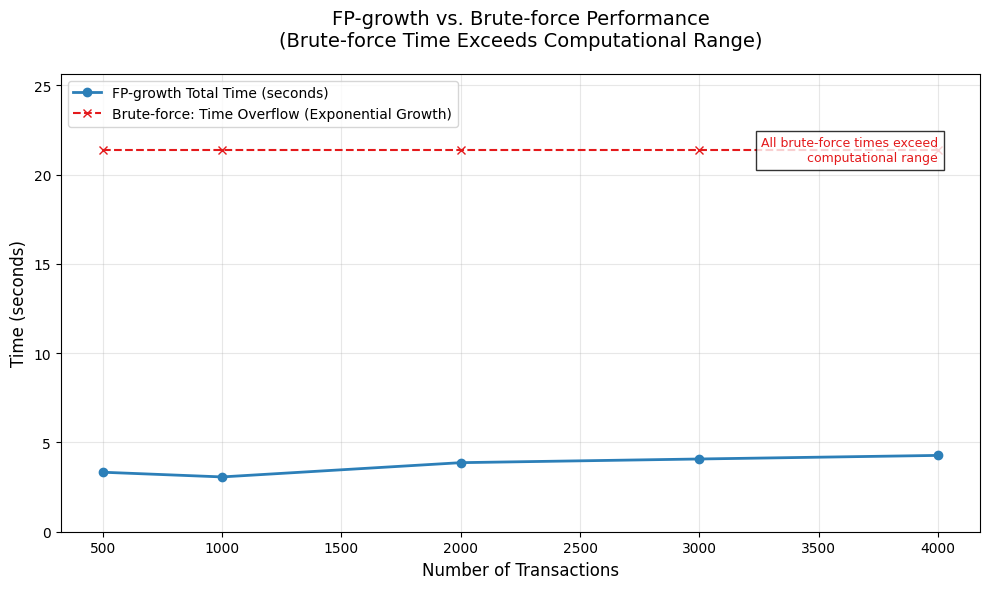

In [14]:
# --------------------------
# Step 5: Visualization 

import matplotlib.pyplot as plt
import numpy as np

# 提取数据
sizes = [r["size"] for r in fp_results]  
fp_times = [r["total_time"] for r in fp_results]  

max_fp_time = max(fp_times) if fp_times else 0
symbolic_brute_time = max_fp_time * 5  

fig, ax = plt.subplots(figsize=(10, 6))


ax.plot(sizes, fp_times, 'o-', color='#2c7fb8', linewidth=2, label='FP-growth Total Time (seconds)')


ax.plot(sizes, [symbolic_brute_time]*len(sizes), 'x--', color='#e41a1c', 
        linewidth=1.5, label='Brute-force: Time Overflow (Exponential Growth)')


ax.text(sizes[-1], symbolic_brute_time, 'All brute-force times exceed\ncomputational range', 
        color='#e41a1c', ha='right', va='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

ax.set_xlabel('Number of Transactions', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_ylim(0, symbolic_brute_time * 1.2)  
ax.grid(alpha=0.3)

ax.legend(loc='upper left', fontsize=10)
plt.title('FP-growth vs. Brute-force Performance\n(Brute-force Time Exceeds Computational Range)', 
          fontsize=14, pad=20)

# 调整布局避免截断
plt.tight_layout()
plt.savefig('fp_vs_brute_overflow.png', dpi=300, bbox_inches='tight')
plt.show()